# Churn Analysis

## Requirements

In [2]:
import sqlite3
from random import choices

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.f2py.rules import check_rules

### Extraction from database

In [3]:
conn = sqlite3.connect('customer_churn.db')
#getting table names
tables = pd.read_sql("""SELECT  name FROM sqlite_master WHERE type='table';""",conn)
print(tables)
#df of separate Tables
dfs = {}
count = 0
for table in tables["name"]:
    dfs[table] = pd.read_sql(f"SELECT * FROM {table};",conn)
    print("DataFrame Created:", tables["name"][count])
    count += 1

conn.close()


              name
0      db_customer
1  db_subscription
2       db_support
DataFrame Created: db_customer
DataFrame Created: db_subscription
DataFrame Created: db_support


In [4]:
for i in dfs.keys():
    print(i)

db_customer
db_subscription
db_support


In [5]:
df_cust = dfs["db_customer"]
df_cust.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [6]:
df_cust.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 1.4+ KB


In [7]:
df_cust.describe()

,customerid,name,country,state,gender,dob,interests,pincode
count,21,21,18,21,21,21,4,0
unique,21,21,2,9,4,21,4,0
top,0002-ORFBO,keshav,India,Delhi,Female,1982-04-12 00:00:00,travel,NaN
freq,1,1,17,4,9,1,1,NaN


In [14]:
#rename cols customer_customer name
df_cust = df_cust.rename(columns = {"name": "customer_name"})
df_cust.head()

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [15]:
#Drop Columns
df_cust.drop(columns = ["interests","pincode"], inplace=True)
df_cust.head()

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00


In [16]:
#change data type to dob

df_cust["dob"] = pd.to_datetime(df_cust["dob"], errors="coerce")

In [17]:
df_cust['gender'] = df_cust['gender'].replace({"Men" : "Male", "Women" : "Female"})

In [20]:
df_cust[df_cust["country"].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [23]:
mapping =  df_cust.dropna(subset = ['country']).set_index('state')['country'].to_dict()
df_cust['country'] = df_cust['country'].fillna(df_cust['state'].map(mapping))
df_cust

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,India,Delhi,Female,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,Nepal,Kathmandu,Female,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [24]:
df_sub = dfs["db_subscription"]
df_sub.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [9]:
df_sub.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 1.9 KB


In [29]:
date_col = ["subscription_start_date","renewal_date","cancellation_date"]
for col in date_col:
    df_sub[col] = pd.to_datetime(df_sub[col], errors="coerce")

In [31]:
df_sub.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 1.9 KB


In [10]:
df_sup = dfs["db_support"]
df_sup.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [11]:
df_sup.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 564.0+ bytes


In [32]:
df_sup.drop(columns = ["col_1","comment"],inplace = True)

In [34]:
df_sup["complaint_date"] = pd.to_datetime(df_sup["complaint_date"], errors="coerce")

In [36]:
df_sup.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 420.0 bytes


# Feature engineering and DataAnalysis

In [39]:
df_sub["churn_flah"] = np.where(df_sub["cancellation_date"].notna(), 1, 0)
df_sub.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flah
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [50]:
df = (df_sub.merge(df_cust, on = "customerid", how = "left").merge(df_sup, on = "customerid", how = "left"))

In [43]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flah,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN


In [51]:
df.shape

(21, 21)

In [46]:
df_sub.shape

(21, 12)

In [47]:
df_sup

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [48]:
df_sup["complaint_count"] = df_sup.groupby("customerid")["customerid"].transform('count')

In [49]:
df_sup = df_sup.sort_values('complaint_date').drop_duplicates('customerid',keep='last')

# DataAnalysis

In [52]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flah', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [57]:
rate = df["churn_flah"].mean() * 100
print("churn rate :", rate , "%")

churn rate : 28.57142857142857 %


In [59]:
retension_rate = 100 - rate
print("Retension rate: ",retension_rate,"%")

Retension rate:  71.42857142857143 %


In [61]:
churn_by_plan = (df.groupby('plan_type')["churn_flah"].mean().mul(100).round(3).reset_index(name='churn_rate_pct'))
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic          60.000
1   Premium          14.286
2  Standard          22.222


In [62]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flah', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [65]:
#ARPU - Average Revenue per User
arpu = df["monthly_charges"].mean()
arpu

np.float64(18.847142857142856)

In [69]:
today = pd.Timestamp.today()

df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
    (today - df['subscription_start_date']).dt.days
)

avg_tenure = df['tenure_days'].mean()

print(f"Avg Tenure: {avg_tenure:.2f} days")

Avg Tenure: 1490.86 days


In [72]:
at_risk = df.loc[df["churn_flah"] == 1, 'monthly_charges'].sum()
print("Revenue Risk", at_risk)

Revenue Risk 73.94


In [74]:
df['escalations'].unique()

<StringArray>
[nan, 'Y', 'N']
Length: 3, dtype: str

In [80]:
escalation_rate = (df['escalations'] == 'Y').mean()*100
print("Escalation Rate", round(escalation_rate,2), "%")

Escalation Rate 19.05 %


In [84]:
#9. Average Complaint Rate
avg_complaint = df["complaint_count"].sum()/ df['customerid'].nunique()
print("Avg_complaints per user :", round(avg_complaint,2), "%")

Avg_complaints per user : 0.43 %


In [89]:
corr_df = df[['escalations',"churn_flah"]].dropna()

df['escalations'] = np.where(df['escalations'] == "Y",1,0)

In [90]:
correlation = corr_df['escalations'].corr(df['churn_flah'])

In [92]:
print("correlation", round(correlation,2), "%")

correlation 0.77 %


In [93]:
df["churn_score"].head()

0    12
1    91
2    34
3     8
4    88
Name: churn_score, dtype: int64

In [94]:
#create a column using exisitng column
conditions = [
    (df["churn_score"] < 50),
    (df["churn_score"] >= 50) & (df["churn_score"] < 70),
    (df["churn_score"] >= 70),
]

choices = ['low','med','high']
df['churn_risk'] = np.select(conditions,choices, default='unkown')

In [95]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,1942.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,0,10.0,2.0,1501.0,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,India,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1327.0,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,India,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2617.0,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,India,Delhi,Female,1990-05-05,2024-01-20,0,20.0,1.0,419.0,high


## Data Visualization

In [96]:
df_visual = df.copy()

In [110]:
#monthly churn trend
df_visual['cancelation_month'] = df_visual['cancellation_date'].dt.to_period("M")

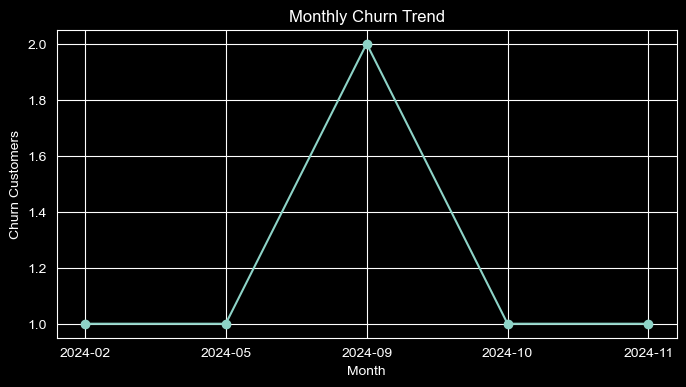

In [116]:
churn_trend = df_visual[df_visual["churn_flah"] == 1].groupby('cancelation_month').size()

plt.figure(figsize = (8,4))
plt.plot(churn_trend.index.astype(str), churn_trend.values,marker = 'o')
plt.title("Monthly Churn Trend")
plt.xlabel("Month")
plt.ylabel("Churn Customers")
plt.show()

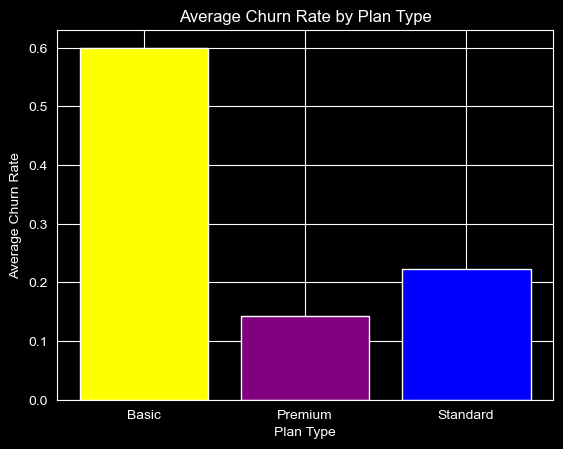

In [122]:
churn_plan = df_visual.groupby("plan_type")["churn_flah"].mean()

colors = ['yellow', 'purple', 'blue']

plt.bar(
    x=churn_plan.index,
    height=churn_plan.values,
    color=colors
)

plt.xlabel("Plan Type")
plt.ylabel("Average Churn Rate")
plt.title("Average Churn Rate by Plan Type")

plt.show()